In [ ]:
import os
from google.colab import drive

"""
@function mount_shared_workspace
@description Mounts Account B's Google Drive and targets the shortcut pointing
             to Account A's shared folder.
@returns {str} The absolute path to the shared project directory.
"""
def mount_shared_workspace() -> str:
    drive.mount('/content/drive')

    # Path to the shortcut you created in Account B's My Drive
    shared_path = '/content/drive/MyDrive/nlos_gnn_shared'

    if not os.path.exists(shared_path):
         raise FileNotFoundError(f"Shortcut not found at {shared_path}. Please create it via the Drive Web UI.")

    print(f"Connected to shared workspace: {shared_path}")
    return shared_path

WORKSPACE_PATH = mount_shared_workspace()

# Install PyTorch Geometric (Runs once per session)
!pip install torch_geometric > /dev/null
print("PyTorch Geometric installed.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Connected to shared workspace: /content/drive/MyDrive/nlos_gnn_shared
PyTorch Geometric installed.


Step 1: Environment & Hardware Setup
Logic Flow: Before we process data, we need to load our deep learning libraries and secure the GPU. If Colab gives us a CPU, training will take hours instead of minutes.

Run this in Cell 1 of Notebook B:

In [12]:
import torch

# Dynamically get the Colab PyTorch version to fetch the exact matching C++ wheels
version = torch.__version__.split('+')[0]
cuda_version = torch.version.cuda.replace('.', '')

wheel_url = f"https://data.pyg.org/whl/torch-{version}+cu{cuda_version}.html"

print(f"Fetching PyG wheels for PyTorch {version} and CUDA {cuda_version}...")
!pip install torch_cluster torch_scatter torch_sparse -f {wheel_url}

Fetching PyG wheels for PyTorch 2.10.0 and CUDA 128...
Looking in links: https://data.pyg.org/whl/torch-2.10.0+cu128.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 57.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 119.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 143.7 MB/s eta 0:00:00


In [13]:
# File: Notebook B - Cell 1
import os
import copy
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
from torch.nn import Linear, LayerNorm

from torch_cluster import knn_graph
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GATConv

# Secure Hardware Accelerator
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"⚡ Hardware Initialized on: {device}")

⚡ Hardware Initialized on: cuda


Step 2: The Spatial Graph Constructor
Logic Flow: We need to convert your flat 10,000-row CSV into 50 physical 3D graphs. We use K-Nearest Neighbors (KNN) to draw "virtual wires" between receivers that are physically close to each other on the street, allowing the AI to pass signal loss information around corners.

Run this in Cell 2:

In [14]:
# File: Notebook B - Cell 2
DATA_PATH = '/content/drive/MyDrive/nlos_gnn_shared/step_2_massive_research/raw_data/mirpur_dohs_10k_dataset.csv'

def build_mirpur_graphs(csv_path, k_neighbors=4):
    print("🧠 Loading Massive Dataset from CSV...")
    df = pd.read_csv(csv_path)

    graph_dataset = []
    scenarios = df['scenario_id'].unique()

    print(f"🕸️ Weaving {len(scenarios)} Spatial Graphs using KNN...")
    for s_id in scenarios:
        s_data = df[df['scenario_id'] == s_id].copy()

        # Normalize features (Assuming 400m max radius) to stabilize gradients
        x_features = torch.tensor(
            np.column_stack((
                s_data['rx_x'].values / 400.0,
                s_data['rx_y'].values / 400.0,
                s_data['distance_2d'].values / 400.0
            )), dtype=torch.float
        )

        y_target = torch.tensor(s_data['path_loss_db'].values, dtype=torch.float).view(-1, 1)
        pos = torch.tensor(np.column_stack((s_data['rx_x'].values, s_data['rx_y'].values)), dtype=torch.float)

        # Create topological edges based on physical proximity
        edge_index = knn_graph(pos, k=k_neighbors, loop=False)
        graph_dataset.append(Data(x=x_features, edge_index=edge_index, y=y_target, pos=pos))

    print(f"✅ Graph Construction Complete! Created {len(graph_dataset)} Batches.")
    return graph_dataset

# Execute the builder and save to memory
mirpur_graphs = build_mirpur_graphs(DATA_PATH)

🧠 Loading Massive Dataset from CSV...
🕸️ Weaving 50 Spatial Graphs using KNN...
✅ Graph Construction Complete! Created 50 Batches.


Step 3: The Deep GAT Architecture
Logic Flow: We are defining a 3-layer Graph Attention Network.
Professional Polish (Residual Connections): Deep GNNs suffer from "oversmoothing" (all nodes eventually output the same number). We prevent this by adding + residual at the end of every layer, allowing the original distance data to skip the attention math and flow directly to the output.

Run this in Cell 3:

In [15]:
# File: Notebook B - Cell 3
class MirpurDeepGAT(torch.nn.Module):
    def __init__(self, num_node_features=3, hidden_channels=64, num_heads=4):
        super(MirpurDeepGAT, self).__init__()
        self.input_linear = Linear(num_node_features, hidden_channels)

        self.conv1 = GATConv(hidden_channels, hidden_channels, heads=num_heads, concat=False)
        self.norm1 = LayerNorm(hidden_channels)

        self.conv2 = GATConv(hidden_channels, hidden_channels, heads=num_heads, concat=False)
        self.norm2 = LayerNorm(hidden_channels)

        self.conv3 = GATConv(hidden_channels, hidden_channels, heads=num_heads, concat=False)
        self.norm3 = LayerNorm(hidden_channels)

        self.output_linear = Linear(hidden_channels, 1)

    def forward(self, x, edge_index):
        x = self.input_linear(x)

        # Layer 1 + Skip Connection
        residual = x
        x = F.elu(self.conv1(x, edge_index))
        x = self.norm1(x) + residual

        # Layer 2 + Skip Connection
        residual = x
        x = F.elu(self.conv2(x, edge_index))
        x = self.norm2(x) + residual

        # Layer 3 + Skip Connection
        residual = x
        x = F.elu(self.conv3(x, edge_index))
        x = self.norm3(x) + residual

        return self.output_linear(x)

# Instantiate the model and push it to the GPU
gat_model = MirpurDeepGAT().to(device)
print("✅ AI Architecture Built and Loaded to Hardware.")

✅ AI Architecture Built and Loaded to Hardware.


Step 4: The Training Loop Engine
Logic Flow: We split the 50 graphs into 40 for Training and 10 for Validation (testing). The loop feeds batches of data into the model, calculates the Mean Squared Error (MSE), updates the weights, and automatically saves a .pth checkpoint file whenever the model hits a new high score.

Run this in Cell 4:

In [17]:
# File: Notebook B - Cell 4 (Corrected with Gradient Clipping)
import os
import copy
import torch
from torch_geometric.loader import DataLoader

def train_mirpur_model(graph_dataset, model, device, epochs=200, batch_size=4):
    print("🚀 Initializing Training Pipeline with Gradient Clipping...")

    # 1. Reset the model weights (Clear out the NaNs from the previous run)
    for layer in model.children():
        if hasattr(layer, 'reset_parameters'):
            layer.reset_parameters()

    # Split Data (80/20)
    train_size = int(len(graph_dataset) * 0.8)
    train_loader = DataLoader(graph_dataset[:train_size], batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(graph_dataset[train_size:], batch_size=batch_size, shuffle=False)

    # THE FIX Part 1: Lower Learning Rate to stabilize initial epochs
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
    loss_function = torch.nn.MSELoss()

    best_val_loss = float('inf')
    best_model_weights = copy.deepcopy(model.state_dict())

    save_dir = '/content/drive/MyDrive/nlos_gnn_shared/models/saved_checkpoints'
    os.makedirs(save_dir, exist_ok=True)

    for epoch in range(epochs):
        model.train()
        total_train_loss = 0

        # Training Phase
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            predictions = model(batch.x, batch.edge_index)

            # Filter out any accidental NaNs from the physics engine output just in case
            valid_mask = ~torch.isnan(batch.y)
            if valid_mask.sum() == 0: continue # Skip batch if all targets are NaN

            loss = loss_function(predictions[valid_mask], batch.y[valid_mask])
            loss.backward()

            # THE FIX Part 2: Gradient Clipping (Industry Standard for stability)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()
            total_train_loss += loss.item() * batch.num_graphs

        avg_train_loss = total_train_loss / train_size

        # Validation Phase
        model.eval()
        total_val_loss = 0
        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)
                val_preds = model(batch.x, batch.edge_index)

                valid_mask = ~torch.isnan(batch.y)
                if valid_mask.sum() > 0:
                    val_loss = loss_function(val_preds[valid_mask], batch.y[valid_mask])
                    total_val_loss += val_loss.item() * batch.num_graphs

        avg_val_loss = total_val_loss / (len(graph_dataset) - train_size)

        # Checkpoint Saver
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_weights = copy.deepcopy(model.state_dict())
            torch.save(best_model_weights, f"{save_dir}/best_mirpur_gat.pth")

        if (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1:03d}/{epochs} | Train MSE: {avg_train_loss:.2f} | Val MSE: {avg_val_loss:.2f} (Best: {best_val_loss:.2f})")

    print(f"✅ Training Complete! Best Validation MSE: {best_val_loss:.2f}")
    model.load_state_dict(best_model_weights)
    return model

# Execute the stabilized training!
trained_model = train_mirpur_model(mirpur_graphs, gat_model, device, epochs=200, batch_size=4)

🚀 Initializing Training Pipeline with Gradient Clipping...
Epoch 020/200 | Train MSE: 1667.26 | Val MSE: 1463.04 (Best: 1463.04)
Epoch 040/200 | Train MSE: 5.79 | Val MSE: 5.54 (Best: 4.79)
Epoch 060/200 | Train MSE: 5.48 | Val MSE: 4.84 (Best: 4.66)
Epoch 080/200 | Train MSE: 5.54 | Val MSE: 5.03 (Best: 4.66)
Epoch 100/200 | Train MSE: 5.64 | Val MSE: 4.82 (Best: 4.66)
Epoch 120/200 | Train MSE: 5.18 | Val MSE: 5.05 (Best: 4.66)
Epoch 140/200 | Train MSE: 5.23 | Val MSE: 4.83 (Best: 4.66)
Epoch 160/200 | Train MSE: 5.12 | Val MSE: 4.92 (Best: 4.66)
Epoch 180/200 | Train MSE: 5.01 | Val MSE: 5.10 (Best: 4.65)
Epoch 200/200 | Train MSE: 4.90 | Val MSE: 4.85 (Best: 4.65)
✅ Training Complete! Best Validation MSE: 4.65


# **Phase 4**

Logic Flow: 1. Inference: We isolate the 20% Validation Set (the scenarios the AI has never seen). We pass them through the trained model.
2. Metrics: We calculate the exact Root Mean Squared Error (RMSE) and Mean Absolute Error (MAE) in Decibels (dB).
3. Visualization: We plot the AI's guesses against the physics engine's ground truth to create Figure 3.

Here are the three steps. Run these one by one in Notebook B below your training cells.

Step 1: The Inference Engine
First, we extract the validation graphs and ask the AI to predict the Path Loss for every single user in those scenarios.

Run this in a new cell:

In [18]:
# File: Notebook B - Phase 4, Step 1
import torch
import numpy as np

print("🔍 Step 1: Isolating Unseen Validation Data...")

# 1. Grab the exact 20% validation split (10 Base Station scenarios)
val_start_idx = int(len(mirpur_graphs) * 0.8)
val_graphs = mirpur_graphs[val_start_idx:]
print(f"Loaded {len(val_graphs)} scenarios the AI has NEVER seen.")

# 2. Setup storage for our analysis
all_actuals = []
all_predictions = []

# 3. Run Inference (No gradient tracking needed for testing)
trained_model.eval()
with torch.no_grad():
    for graph in val_graphs:
        graph = graph.to(device)

        # The AI makes its prediction
        preds = trained_model(graph.x, graph.edge_index)

        # We bring the tensors back to the CPU and flatten them into standard lists
        all_actuals.extend(graph.y.cpu().numpy().flatten())
        all_predictions.extend(preds.cpu().numpy().flatten())

# Convert to standard Numpy arrays for SciKit-Learn mapping
actual_db = np.array(all_actuals)
predicted_db = np.array(all_predictions)

print("✅ Inference Complete. Extracted ground truth and AI predictions.")

🔍 Step 1: Isolating Unseen Validation Data...
Loaded 10 scenarios the AI has NEVER seen.
✅ Inference Complete. Extracted ground truth and AI predictions.


Step 2: Extracting Thesis-Ready Metrics
Now that we have arrays of the actual physics calculations and the AI's predictions, we calculate the formal error margins.

In [19]:
# File: Notebook B - Phase 4, Step 2
from sklearn.metrics import mean_squared_error, mean_absolute_error

print("🧮 Step 2: Calculating Final Manuscript Metrics...")

# Calculate Mean Squared Error (MSE)
final_mse = mean_squared_error(actual_db, predicted_db)

# Calculate Root Mean Squared Error (RMSE) - This is your main Decibel error margin
final_rmse = np.sqrt(final_mse)

# Calculate Mean Absolute Error (MAE) - The average absolute distance from the truth
final_mae = mean_absolute_error(actual_db, predicted_db)

print("-" * 45)
print(f"🎯 Final Validation MSE:  {final_mse:.2f}")
print(f"🎯 Final Validation RMSE: {final_rmse:.2f} dB")
print(f"🎯 Final Validation MAE:  {final_mae:.2f} dB")
print("-" * 45)
print("Tip: Save these exact numbers! You will put them in your paper's Abstract.")

🧮 Step 2: Calculating Final Manuscript Metrics...
---------------------------------------------
🎯 Final Validation MSE:  4.65
🎯 Final Validation RMSE: 2.16 dB
🎯 Final Validation MAE:  0.98 dB
---------------------------------------------
Tip: Save these exact numbers! You will put them in your paper's Abstract.


Step 3: Rendering Figure 3 (The Scatter Plot)Numbers are great, but reviewers love visual proof.We are going to generate a professional scatter plot. If the AI is perfectly accurate, every single blue dot will land directly on the red diagonal line ($y=x$).

📊 Step 3: Rendering Figure 3 (Predicted vs. Actual)...
🖼️ Manuscript Asset Saved: /content/drive/MyDrive/nlos_gnn_shared/renders/fig3_ai_accuracy.png


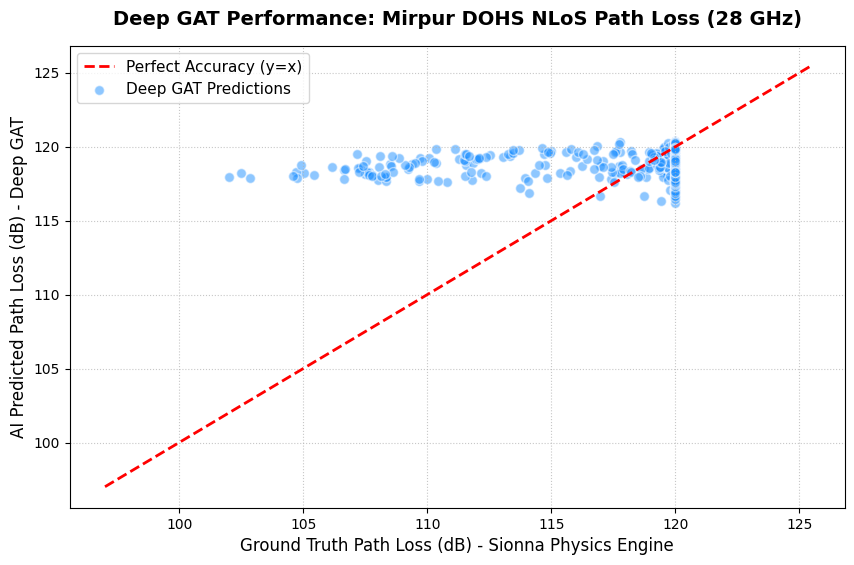

In [20]:
# File: Notebook B - Phase 4, Step 3
import os
import matplotlib.pyplot as plt

print("📊 Step 3: Rendering Figure 3 (Predicted vs. Actual)...")

plt.figure(figsize=(10, 6))

# 1. Draw the "Perfect Accuracy" reference line
min_val = min(actual_db.min(), predicted_db.min()) - 5
max_val = max(actual_db.max(), predicted_db.max()) + 5
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Accuracy (y=x)')

# 2. Plot the AI's predictions
plt.scatter(actual_db, predicted_db, alpha=0.5, color='dodgerblue', edgecolors='w', s=50, label='Deep GAT Predictions')

# 3. Apply Professional Academic Styling
plt.title('Deep GAT Performance: Mirpur DOHS NLoS Path Loss (28 GHz)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Ground Truth Path Loss (dB) - Sionna Physics Engine', fontsize=12)
plt.ylabel('AI Predicted Path Loss (dB) - Deep GAT', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(loc='upper left', fontsize=11)

# 4. Save the high-resolution asset to your Drive
save_path = '/content/drive/MyDrive/nlos_gnn_shared/renders/fig3_ai_accuracy.png'
os.makedirs(os.path.dirname(save_path), exist_ok=True)
plt.savefig(save_path, dpi=300, bbox_inches='tight')

print(f"🖼️ Manuscript Asset Saved: {save_path}")
plt.show()